## Waste Detection and Classification System

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [7]:
# path comes from kagglehub.dataset_download(...)
import os
dataset_path = "Waste_Dataset"

# sanity check
print("Dataset path:", dataset_path)
print("Path exists:", os.path.exists(dataset_path))

# list classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Dataset path: Waste_Dataset
Path exists: True
Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


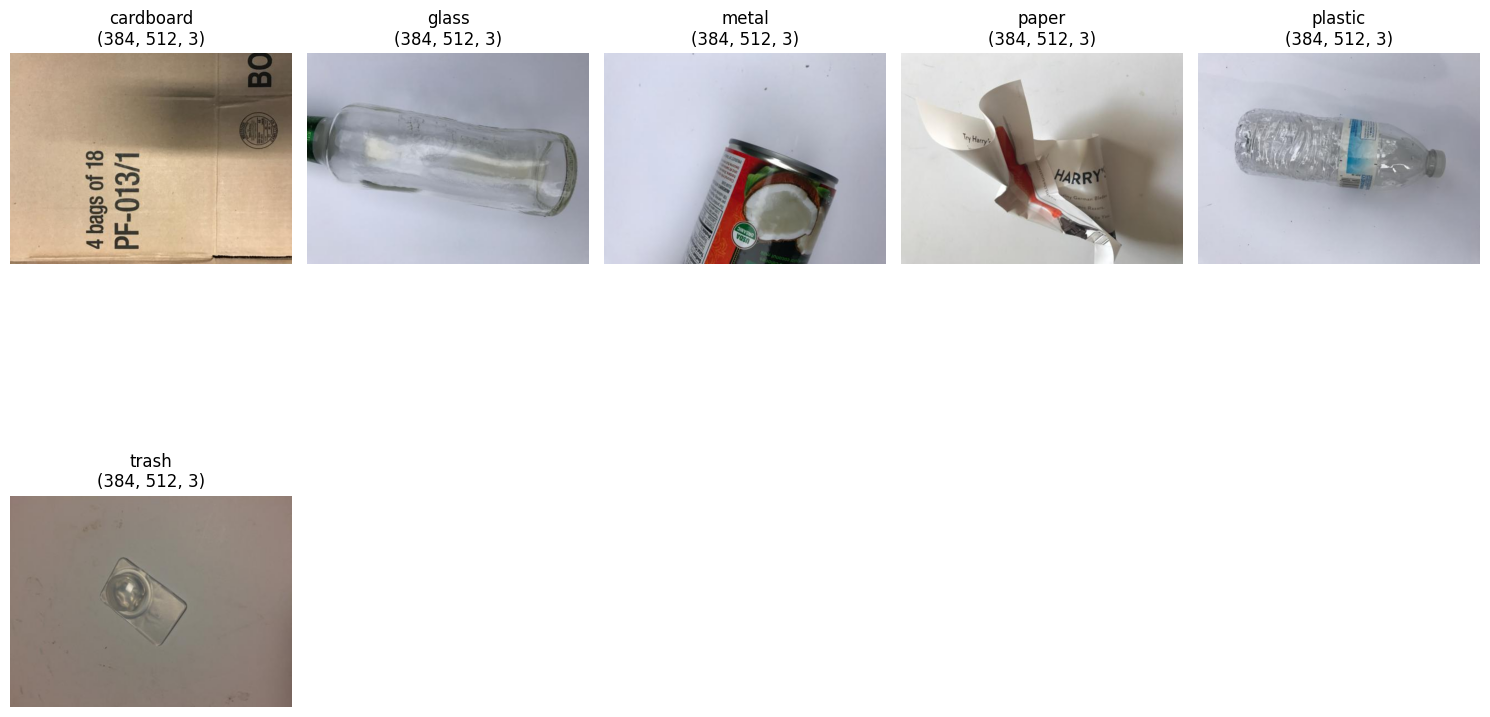

In [8]:
import random

def visualize_sample_images(dataset_path, classes, num_images=10):
    plt.figure(figsize=(15, 10))

    cols = 5
    rows = (num_images + cols - 1) // cols

    for i, class_name in enumerate(classes[:num_images]):
        class_path = os.path.join(dataset_path, class_name)
        img_list = os.listdir(class_path)

        if not img_list:
            continue

        try:
            img_name = random.choice(img_list)
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f'{class_name}\n{img.shape}')
            plt.axis('off')

        except Exception as e:
            print(f"Error loading image from {class_name}: {e}")

    plt.tight_layout()
    plt.show()
visualize_sample_images(dataset_path, classes)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Define image size and batch_size
img_size = 224
batch_size = 32

# Slightly improved Data Augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [10]:
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 as the base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model weights, training
base_model.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x) # output layer

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Model summary
model.summary()

2026-03-26 17:39:14.155203: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-26 17:39:14.155224: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 17:39:14.155231: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 17:39:14.155246: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 17:39:14.155255: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/Users/namanpatel/Documents/Coding/Python /Machine Learning/venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


2026-03-26 17:39:15.635813: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - accuracy: 0.2536 - loss: 2.3580 - val_accuracy: 0.4632 - val_loss: 1.3474
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.4326 - loss: 1.6983 - val_accuracy: 0.5527 - val_loss: 1.1703
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.5011 - loss: 1.4554 - val_accuracy: 0.6004 - val_loss: 1.0125
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.5644 - loss: 1.2100 - val_accuracy: 0.6541 - val_loss: 0.9601
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.6130 - loss: 1.2065 - val_accuracy: 0.6620 - val_loss: 0.9065
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.6183 - loss: 1.1290 - val_accuracy: 0.6421 - val_loss: 0.8693
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.6404 - loss: 1.0451 - val_accuracy: 0.6879 - val_loss: 0.8297
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.6639 - loss: 0.9951 - val_accuracy: 0.7018 - v

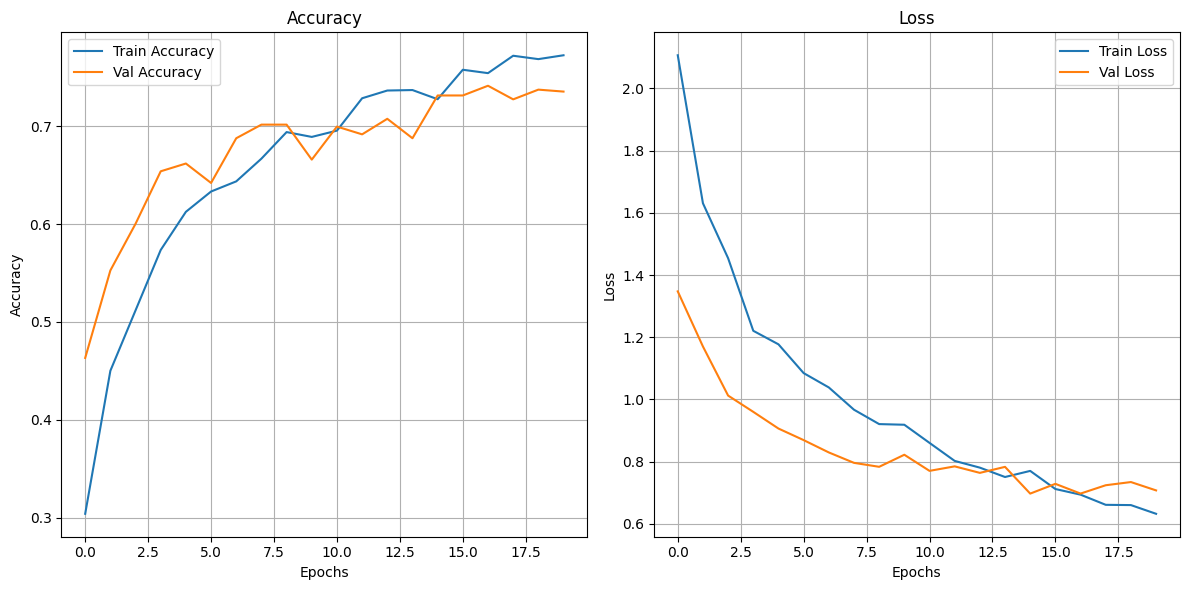

In [12]:
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history.get('accuracy', []), label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history.get('loss', []), label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(val_data)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.7404 - loss: 0.7150
Validation Loss: 0.7316089272499084
Validation Accuracy: 0.7216699719429016


In [21]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


In [22]:
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [23]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Load class names once (IMPORTANT)
class_names = list(train_generator.class_indices.keys())

def predict(img_path):
    if not os.path.exists(img_path):
        print("❌ Invalid image path")
        return
    
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for MobileNetV2
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    pred_index = np.argmax(prediction)
    confidence = np.max(prediction)

    predicted_class = class_names[pred_index]

    # Output
    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2f}")

    # Show image
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction: metal
Confidence: 1.00


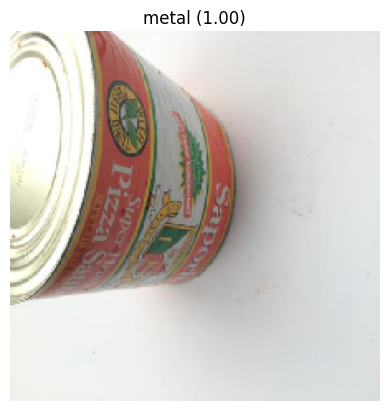

In [25]:
# Example usage
test_image_path = "Waste_Dataset/metal/metal1.jpg" 
predict(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction: cardboard
Confidence: 1.00


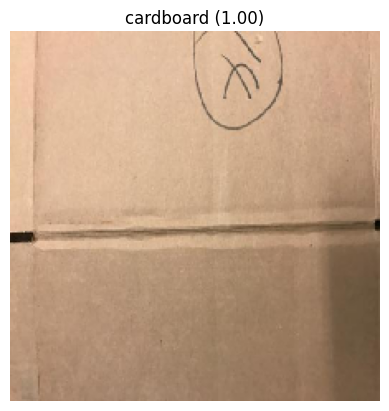

In [ ]:
# Example usage
test_image_path = "Waste_Dataset/cardboard/cardboard1.jpg"
predict(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction: plastic
Confidence: 0.98


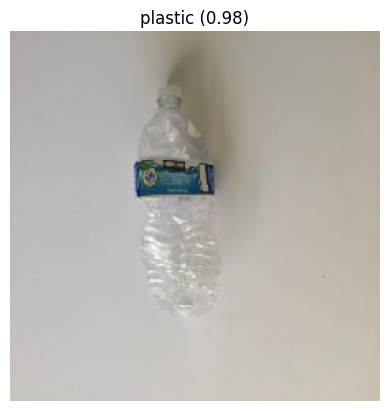

In [ ]:
# Example usage
test_image_path = "Waste_Dataset/Plastic/plastic5.jpg"  
predict(test_image_path) 